In [1]:
import models.model as modelgen
from configs import config
import torch
import torch.nn as nn
import utils.log as log
import json
import numpy as np

In [2]:
def get_dct_matrix(N):
    dct_m = np.eye(N)
    for k in np.arange(N):
        for i in np.arange(N):
            w = np.sqrt(2 / N)
            if k == 0:
                w = np.sqrt(1 / N)
            dct_m[k, i] = w * np.cos(np.pi * (i + 1 / 2) * k / N)
    idct_m = np.linalg.inv(dct_m)
    return dct_m, idct_m

dct_m, idct_m = get_dct_matrix(4)

In [3]:
a = torch.arange(32*32*99*3, dtype=torch.double) - 5
B = a.reshape((32, 32, 99*3))
dct_m, idct_m = get_dct_matrix(32)
dct_m = torch.tensor(dct_m).unsqueeze(0)
idct_m = torch.tensor(idct_m).unsqueeze(0)
torch.matmul(dct_m, B).shape

torch.Size([32, 32, 297])

In [4]:
torch.matmul(idct_m, torch.matmul(dct_m, B)).shape

torch.Size([32, 32, 297])

In [5]:
from torch import linalg as LA

a = torch.arange(32*32*99*3, dtype=torch.float) - 5
B = a.reshape((32, 32, 99*3))
c = torch.arange(32*32*99*3, dtype=torch.float)
D = c.reshape((32, 32, 99*3))
loss = torch.mean(LA.vector_norm(B-D, 2, -1))
LA.vector_norm(B-D, 2, -1).shape
loss

tensor(86.1684)

In [6]:
a = torch.arange(32*32*99*3, dtype=torch.float) - 5
B = a.reshape((-1, 99*3))
c = torch.arange(32*32*99*3, dtype=torch.float)
D = c.reshape((-1, 99*3))
loss = torch.mean(LA.vector_norm(B-D, 2, 1))
LA.vector_norm(B-D, 2, 1).shape
loss

tensor(86.1684)

In [7]:
def gen_velocity(m):
    dm = m[:, 1:] - m[:, :-1]
    return dm
dloss = LA.vector_norm(gen_velocity(B)-gen_velocity(D), 2, -1)
dloss.shape

torch.Size([1024])

In [8]:
cfgs = config.Configurations('./configs/LSFB/siMLPe/vanilla.yaml')

logger = log.make_logger('./logs/testing/', "test", None)
logger.info("Run name : {run_name}".format(run_name='test'))
for k, v in cfgs.super_cfgs.items():
    logger.info("cfgs." + k + " =")
    logger.info(json.dumps(vars(v), indent=2))

[INFO] 2024-05-15 18:08:28 > Run name : test
[INFO] 2024-05-15 18:08:28 > cfgs.DATA =
[INFO] 2024-05-15 18:08:28 > {
  "name": "LSFB",
  "input_size": [
    24,
    99,
    3
  ],
  "num_classes": 610,
  "min_samples": 20,
  "max_len": 32,
  "target_len": 8,
  "oversample": true,
  "poses": [
    [
      "pose",
      "all"
    ],
    [
      "right_hand",
      "all"
    ],
    [
      "left_hand",
      "all"
    ],
    [
      "face",
      [
        61,
        39,
        0,
        269,
        291,
        405,
        17,
        181,
        33,
        159,
        133,
        145,
        46,
        52,
        65,
        55,
        263,
        386,
        362,
        374,
        276,
        282,
        295,
        285
      ]
    ]
  ],
  "num_keypoints": 99,
  "flip_p": 0.0,
  "scale": 0.0,
  "random_crop": false,
  "drop_frame": 0.0,
  "drop_keypoint": 0.0,
  "block_size": 5,
  "rot": 0.0
}
[INFO] 2024-05-15 18:08:28 > cfgs.MODEL =
[INFO] 2024-05-15 18:08:28 > 

In [9]:
rank = torch.cuda.current_device()
model = modelgen.load_model(DATA=cfgs.DATA,
                                MODEL=cfgs.MODEL,
                                MODULES=cfgs.MODULES,
                                RUN=cfgs.RUN,
                                device=rank,
                                logger=logger)

[INFO] 2024-05-15 18:08:29 > Build the model.
[INFO] 2024-05-15 18:08:29 > Modules are located on './src/models.siMLPe'.
[INFO] 2024-05-15 18:08:29 > Number of parameters: 181788
[INFO] 2024-05-15 18:08:29 > Model(
  (arr0): Rearrange('b n d -> b d n')
  (arr1): Rearrange('b d n -> b n d')
  (motion_mlp): TransMLP(
    (mlps): Sequential(
      (0): MLPblock(
        (fc0): Temporal_FC(
          (fc): Linear(in_features=24, out_features=24, bias=True)
        )
        (norm0): SLayerNorm()
      )
      (1): MLPblock(
        (fc0): Temporal_FC(
          (fc): Linear(in_features=24, out_features=24, bias=True)
        )
        (norm0): SLayerNorm()
      )
      (2): MLPblock(
        (fc0): Temporal_FC(
          (fc): Linear(in_features=24, out_features=24, bias=True)
        )
        (norm0): SLayerNorm()
      )
      (3): MLPblock(
        (fc0): Temporal_FC(
          (fc): Linear(in_features=24, out_features=24, bias=True)
        )
        (norm0): SLayerNorm()
      )
   

In [10]:
from torchinfo import summary

batch_size = 32
summary(model, input_size=(batch_size, 24,99*3), depth=1)

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [32, 24, 297]             --
├─Linear: 1-1                            [32, 24, 297]             88,506
├─Rearrange: 1-2                         [32, 297, 24]             --
├─TransMLP: 1-3                          [32, 297, 24]             4,776
├─Rearrange: 1-4                         [32, 24, 297]             --
├─Linear: 1-5                            [32, 24, 297]             88,506
Total params: 181,788
Trainable params: 181,788
Non-trainable params: 0
Total mult-adds (M): 5.74
Input size (MB): 0.91
Forward/backward pass size (MB): 18.25
Params size (MB): 0.73
Estimated Total Size (MB): 19.89

In [11]:
# Generate a random input tensor
input_tensor = torch.randn(32, cfgs.DATA.input_size[0], cfgs.DATA.input_size[1]*cfgs.DATA.input_size[2]).to(rank)

# Pass the input tensor through the model
output_tensor = model(input_tensor)

# Print the output tensor
print(output_tensor.shape)

torch.Size([32, 24, 297])


In [12]:
from data.data_util import Dataset_, train_val_dataset, OversamplingWrapper
import utils.misc as misc

data_name = "LSFB"
data_dir = "/mnt/sda2/datasets/isolated-cont-sl/LSFB/"
poses = [["pose","all"],["right_hand","all"],["left_hand","all"], ["face",[61,39,0,269,291,405,17,181,33,159,133,145,46,52,65,55,263,386,362,374,276,282,295,285]]]
dset_used = 1
seed = 42
oversample = True

print("Load {name} train dataset.".format(name=data_name))
train_dataset = Dataset_(data_dir=data_dir,
                            train=True,
                            load_data_in_memory=False,
                            poses=poses,
                            max_len=32,
                            min_samples=20,
                            target_len=8,
                            mode="prediction")
print("Train dataset size: {dataset_size}".format(dataset_size=len(train_dataset)))


Load LSFB train dataset.
Train dataset size: 52350


In [13]:
import torch.utils.benchmark as benchmark

input = train_dataset[0]
values = torch.reshape(input[0], (1,input[0].shape[0],input[0].shape[1])).to(rank)

def stepmodel(input):
    with torch.autocast("cuda"):
        # Pass the input tensor through the model
        output_tensor = model(input.float())
    return output_tensor

t0 = benchmark.Timer(
    stmt='stepmodel(x)',
    setup='from __main__ import stepmodel',
    globals={'x': values},
    num_threads=4)

print(t0.timeit(100))

stepmodel(x)
setup: from __main__ import stepmodel
  1.51 ms
  1 measurement, 100 runs , 4 threads


In [16]:
input = torch.unflatten(train_dataset[0][0], 1, (99, 3))
body_kp = input[:,:33,:]
rhand_kp = input[:,33:(33+21),:]
lhand_kp = input[:,(33+21):(33+21+21),:]
face_kp = input[:,(33+21+21):,:]
body_kp

tensor([[[-0.0598, -1.0000, -1.0014],
         [ 0.8292, -1.3202, -0.6345],
         [ 1.4926, -1.3345, -0.6416],
         ...,
         [-6.6940,  6.8483,  7.6564],
         [-7.5830,  7.8141,  4.7069],
         [-8.2730,  7.4063,  6.6967]],

        [[-0.0200, -1.0161, -0.5675],
         [ 0.8425, -1.3327, -0.1794],
         [ 1.4926, -1.3452, -0.1865],
         ...,
         [-6.0837,  6.7839,  8.2420],
         [-6.7604,  7.7998,  4.6364],
         [-7.5432,  7.3920,  7.5717]],

        [[ 0.0198, -1.0286, -0.2853],
         [ 0.8690, -1.3416,  0.0817],
         [ 1.5059, -1.3523,  0.0746],
         ...,
         [-5.5928,  6.5836,  8.7924],
         [-6.7338,  7.7426,  4.5482],
         [-7.3177,  7.2418,  8.4184]],

        ...,

        [[-0.0731, -1.0358, -1.2802],
         [ 0.8425, -1.3506, -0.9485],
         [ 1.4263, -1.3613, -0.9556],
         ...,
         [-5.3008,  6.7767,  8.7077],
         [-6.6940,  7.7640,  4.9327],
         [-7.0788,  7.3133,  8.1080]],

        [[

In [17]:
body_kp.shape

torch.Size([24, 33, 3])

In [18]:
def i_normalize(data, pose):
    mean = {
        'pose': [0.0011, 0.1365, 0.0693],
        'right_hand': [-0.0325,  0.1191,  0.0000],
        'left_hand': [0.0251, 0.1365, 0.0000],
        'face': [-0.0024, -0.0086,  0.1384]
    }
    std = {
        'pose': [0.0184, 0.1365, 0.0692],
        'right_hand': [0.0111, 0.0222, 42],
        'left_hand': [0.0105, 0.0198, 42],
        'face': [0.0046, 0.0086, 0.0040]
    }

    mean = np.array(mean[pose])
    std = np.array(std[pose])

    mean = mean[None, None, :]
    std = std[None, None, :]

    # Normalize the data
    normalized_data = data * std + mean

    return normalized_data
i_normalize(body_kp, 'pose')

tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 1.6357e-02, -4.3701e-02,  2.5391e-02],
         [ 2.8564e-02, -4.5654e-02,  2.4902e-02],
         ...,
         [-1.2207e-01,  1.0713e+00,  5.9912e-01],
         [-1.3843e-01,  1.2031e+00,  3.9502e-01],
         [-1.5112e-01,  1.1475e+00,  5.3271e-01]],

        [[ 7.3242e-04, -2.1973e-03,  3.0029e-02],
         [ 1.6602e-02, -4.5410e-02,  5.6885e-02],
         [ 2.8564e-02, -4.7119e-02,  5.6396e-02],
         ...,
         [-1.1084e-01,  1.0625e+00,  6.3965e-01],
         [-1.2329e-01,  1.2012e+00,  3.9014e-01],
         [-1.3770e-01,  1.1455e+00,  5.9326e-01]],

        [[ 1.4648e-03, -3.9062e-03,  4.9561e-02],
         [ 1.7090e-02, -4.6631e-02,  7.4951e-02],
         [ 2.8809e-02, -4.8096e-02,  7.4463e-02],
         ...,
         [-1.0181e-01,  1.0352e+00,  6.7773e-01],
         [-1.2280e-01,  1.1934e+00,  3.8403e-01],
         [-1.3354e-01,  1.1250e+00,  6.5186e-01]],

        ...,

        [[-2.4414e-04, -4.8828e-03, -1

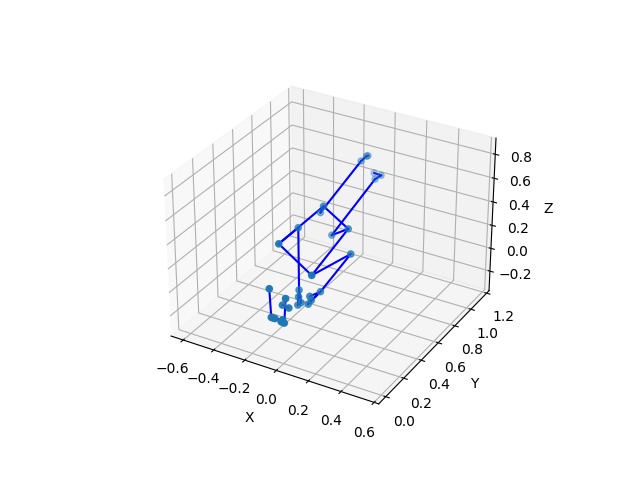

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib ipympl

# MediaPipe pose landmarks connection (in their order)
POSE_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8), (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (11, 23), (12, 14), (14, 16), (15,19), (15,21), (16,22), (16,20), (20,18), (19,17), (16, 18), (12, 24), (23, 24), (23, 25), (25, 27), (27, 29), (29, 31), (24, 26), (26, 28), (28, 30), (30, 32)]
FACE_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 0), 
                    (8, 9), (9, 10), (10, 11), (11, 8),
                    (12, 13), (13, 14), (14, 15),
                    (16, 17), (17, 18), (18, 19), (19, 16),
                    (20, 21), (21, 22), (22, 23)]
HAND_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 4), (0, 5), (0, 17), (5, 9), (9, 13), (13, 17), (5, 6), (6, 7), (7, 8), (9, 10), (10, 11), (11, 12), (13, 14), (14, 15), (15, 16), (17, 18), (18, 19), (19, 20)]

def plot_keypoints(xyz_keypoints, connections):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    xs = xyz_keypoints[:, 0]
    ys = xyz_keypoints[:, 1]
    zs = xyz_keypoints[:, 2]

    ax.scatter(xs, ys, zs)

    for connection in connections:
        start = connection[0]
        end = connection[1]

        ax.plot([xs[start], xs[end]], [ys[start], ys[end]], [zs[start], zs[end]], 'blue')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Set aspect ratio
    max_range = np.array([xs.max()-xs.min(), ys.max()-ys.min(), zs.max()-zs.min()]).max() / 2.0
    mid_x = (xs.max()+xs.min()) * 0.5
    mid_y = (ys.max()+ys.min()) * 0.5
    mid_z = (zs.max()+zs.min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.show()
plot_keypoints(i_normalize(body_kp, 'pose')[20], POSE_CONNECTIONS)

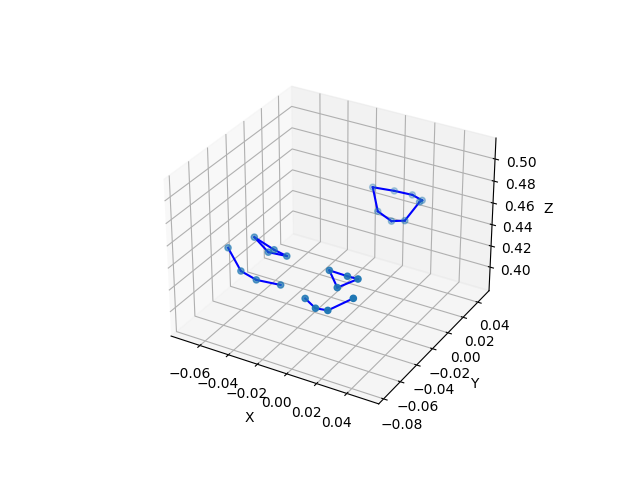

In [20]:
plot_keypoints(i_normalize(face_kp, 'face')[20], FACE_CONNECTIONS)

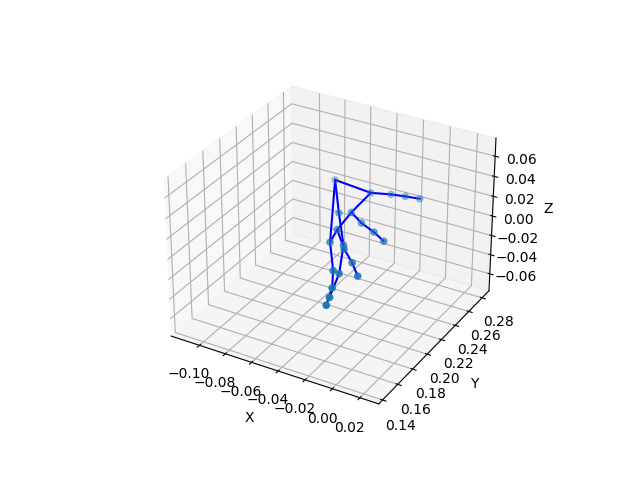

In [21]:
plot_keypoints(i_normalize(rhand_kp, 'right_hand')[20], HAND_CONNECTIONS)

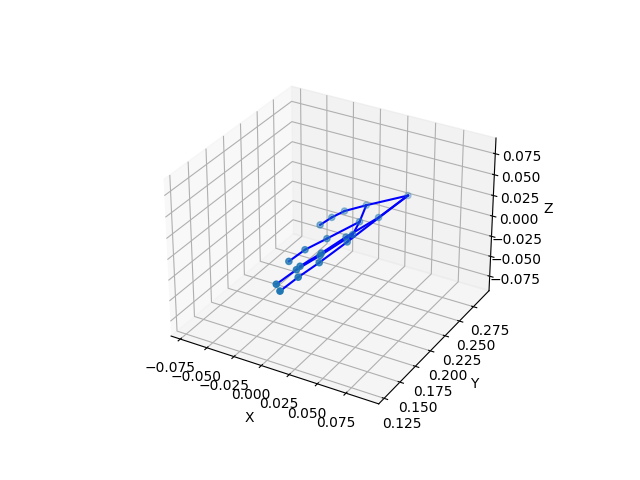

In [22]:
plot_keypoints(i_normalize(lhand_kp, 'left_hand')[20], HAND_CONNECTIONS)

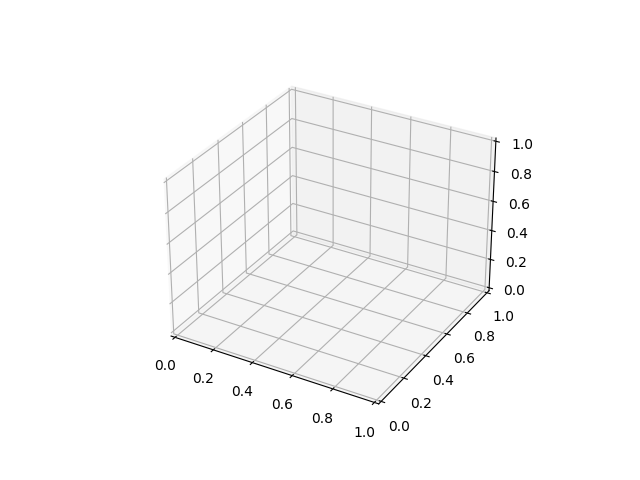

In [23]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import numpy as np
%matplotlib ipympl

# MediaPipe pose landmarks connection (in their order)
POSE_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8), (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (11, 23), (12, 14), (14, 16), (15,19), (15,21), (16,22), (16,20), (20,18), (19,17), (16, 18), (12, 24), (23, 24), (23, 25), (25, 27), (27, 29), (29, 31), (24, 26), (26, 28), (28, 30), (30, 32)]
FACE_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 0), 
                    (8, 9), (9, 10), (10, 11), (11, 8),
                    (12, 13), (13, 14), (14, 15),
                    (16, 17), (17, 18), (18, 19), (19, 16),
                    (20, 21), (21, 22), (22, 23)]
HAND_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 4), (0, 5), (0, 17), (5, 9), (9, 13), (13, 17), (5, 6), (6, 7), (7, 8), (9, 10), (10, 11), (11, 12), (13, 14), (14, 15), (15, 16), (17, 18), (18, 19), (19, 20)]

def animate_keypoints(xyz_keypoints, connections):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    xss = xyz_keypoints[:, :, 0]
    yss = xyz_keypoints[:, :, 1]
    zss = xyz_keypoints[:, :, 2]

    def animate(i):
        ax.cla()   
        xs = xss[i]
        ys = yss[i]
        zs = zss[i]
        ax.scatter(xs, ys, zs)

        for connection in connections:
            start = connection[0]
            end = connection[1]

            ax.plot([xs[start], xs[end]], [ys[start], ys[end]], [zs[start], zs[end]], 'blue')

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

        # Set aspect ratio
        max_range = np.array([xss[0].max()-xss[0].min(), yss[0].max()-yss[0].min(), zss[0].max()-zss[0].min()]).max() / 2.0
        mid_x = (xss[0].max()+xss[0].min()) * 0.5
        mid_y = (yss[0].max()+yss[0].min()) * 0.5
        mid_z = (zss[0].max()+zss[0].min()) * 0.5
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)

        ax.view_init(-70, -90)

    
    ani = animation.FuncAnimation(fig, animate, repeat=False,
                                        frames=len(xyz_keypoints) - 1, interval=50)

    plt.show()

animate_keypoints(i_normalize(body_kp, 'pose'), POSE_CONNECTIONS)

/home/grios/myphyton/lib/python3.10/site-packages/matplotlib/animation.py:887: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you have outputted the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


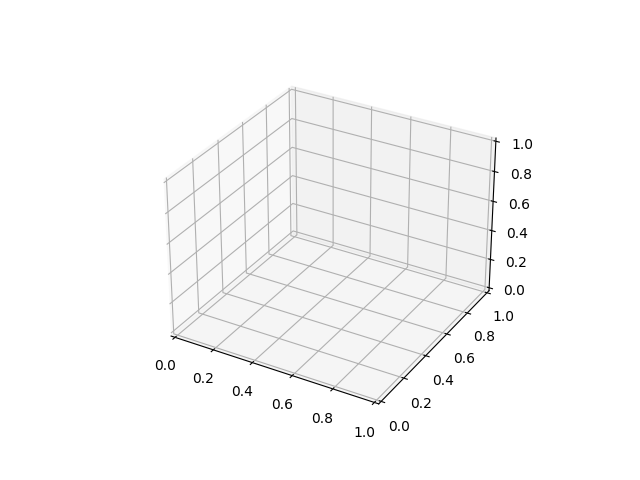

In [24]:
animate_keypoints(i_normalize(face_kp, 'face'), FACE_CONNECTIONS)

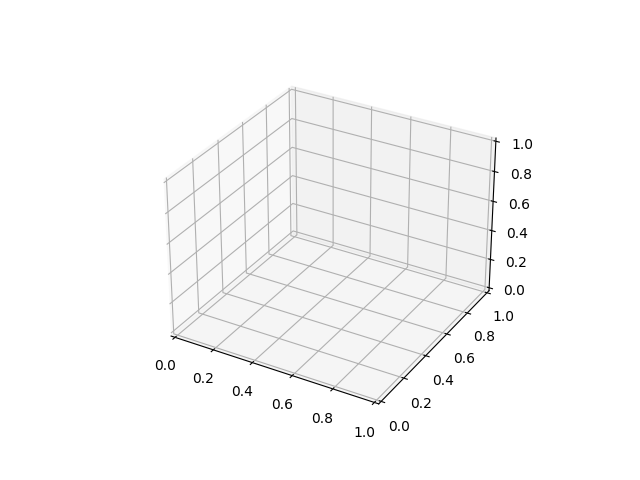

In [25]:
animate_keypoints(i_normalize(rhand_kp, 'right_hand'), HAND_CONNECTIONS)

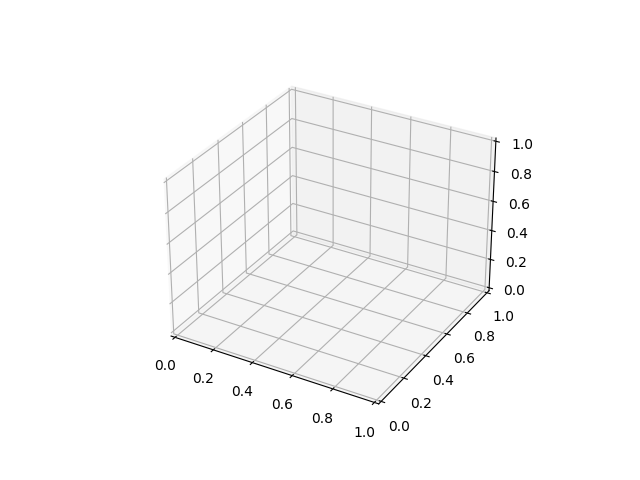

In [26]:
animate_keypoints(i_normalize(lhand_kp, 'left_hand'), HAND_CONNECTIONS)